# Week 3 · Lecture 3 — Hamiltonian Monte Carlo

## Learning objectives

1. Understand why naive MH fails in high dimensions and why **gradient information** rescues it.
2. Derive **Hamiltonian Monte Carlo (HMC)** from the physical analogy: the target density is a potential well, and we simulate fictional Hamiltonian dynamics to explore it.
3. Implement HMC with the **leapfrog integrator** from scratch.
4. Compare HMC's mixing properties against random-walk MH on a strongly correlated Gaussian target.
5. Touch on NUTS as the practical default in `PyMC` / `NumPyro`.

## 1. Why MH dies in high dimensions

For an isotropic Gaussian target in $D$ dimensions and Gaussian proposal $\mathcal{N}(0, \epsilon^2 I)$, the optimal acceptance rate is $\approx 0.234$ and the step size needs to scale as $\epsilon \sim D^{-1/2}$. So in $D = 1000$ dimensions, random-walk MH explores at rate $\sim D^{-1/2} = O(0.03)$ per step — astronomically slow.

The cure is to use the **gradient of the log target**. HMC does this by simulating a fictitious particle moving through the parameter space.

## 2. The Hamiltonian

Augment $\theta$ with auxiliary "momentum" variables $r \sim \mathcal{N}(0, M)$ where $M$ is a positive-definite **mass matrix**. The joint distribution

$$
p(\theta, r) \;=\; p(\theta \mid \mathcal{D})\, \mathcal{N}(r \mid 0, M)
$$

factorises, so marginalising over $r$ recovers the target. Define the *Hamiltonian*

$$
H(\theta, r) = -\log p(\theta \mid \mathcal{D}) + \tfrac{1}{2} r^\top M^{-1} r,
$$

so $p(\theta, r) \propto e^{-H(\theta, r)}$. Hamilton's equations

$$
\dot\theta = \frac{\partial H}{\partial r} = M^{-1} r, \qquad \dot r = -\frac{\partial H}{\partial \theta} = \nabla \log p(\theta \mid \mathcal{D}),
$$

conserve $H$ exactly and preserve volume in $(\theta, r)$-space, so they propose states $(\theta', r')$ at which $H(\theta', r') = H(\theta, r)$. If we could integrate exactly, the MH acceptance would always be 1.

In practice we use the **leapfrog integrator** — a symplectic discretisation:

$$
r \leftarrow r + \tfrac{\epsilon}{2} \nabla \log p(\theta), \qquad \theta \leftarrow \theta + \epsilon M^{-1} r, \qquad r \leftarrow r + \tfrac{\epsilon}{2} \nabla \log p(\theta).
$$

It is reversible and preserves volume but not energy. The energy drift is corrected by an MH step at the end, with acceptance

$$
\alpha = \min(1, \exp(H(\theta, r) - H(\theta', r'))).
$$

Tune $\epsilon$ (step size) and $L$ (number of leapfrog steps) for good performance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
def leapfrog(theta, r, grad_log_p, epsilon, L):
    # In-place leapfrog steps. Returns the proposed (theta', r').
    theta = theta.copy()
    r = r.copy()
    r += 0.5 * epsilon * grad_log_p(theta)
    for _ in range(L - 1):
        theta += epsilon * r
        r += epsilon * grad_log_p(theta)
    theta += epsilon * r
    r += 0.5 * epsilon * grad_log_p(theta)
    return theta, r


def hmc(log_p, grad_log_p, theta0, n_samples, epsilon=0.1, L=20, rng=None):
    rng = rng or np.random.default_rng(0)
    theta = np.array(theta0, dtype=float)
    D = theta.shape[0]
    chain = np.empty((n_samples, D))
    n_accept = 0

    for t in range(n_samples):
        r = rng.normal(size=D)
        theta_prop, r_prop = leapfrog(theta, r, grad_log_p, epsilon, L)
        H_curr = -log_p(theta) + 0.5 * r @ r
        H_prop = -log_p(theta_prop) + 0.5 * r_prop @ r_prop
        if np.log(rng.uniform()) < H_curr - H_prop:
            theta = theta_prop
            n_accept += 1
        chain[t] = theta

    return chain, n_accept / n_samples


## 3. Demo: a strongly correlated 2D Gaussian

Target: $\mathcal{N}(\mathbf{0}, \Sigma)$ with $\Sigma = \begin{pmatrix} 1 & 0.98 \\ 0.98 & 1 \end{pmatrix}$. This is exactly the kind of geometry that destroys random-walk MH: a thin ridge along the diagonal. HMC should glide through it.


In [3]:
rho = 0.98
Sigma = np.array([[1.0, rho], [rho, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)

def log_p(theta): return -0.5 * theta @ Sigma_inv @ theta
def grad_log_p(theta): return -Sigma_inv @ theta

# Random-walk MH baseline
def metropolis(log_target, theta0, n_samples, scale, rng):
    theta = np.array(theta0, dtype=float)
    D = theta.shape[0]
    chain = np.empty((n_samples, D))
    log_p_curr = log_target(theta)
    n_acc = 0
    for t in range(n_samples):
        theta_prop = theta + rng.normal(scale=scale, size=D)
        log_p_prop = log_target(theta_prop)
        if np.log(rng.uniform()) < log_p_prop - log_p_curr:
            theta = theta_prop; log_p_curr = log_p_prop; n_acc += 1
        chain[t] = theta
    return chain, n_acc / n_samples


rng = np.random.default_rng(0)
chain_mh, acc_mh = metropolis(log_p, [3.0, -3.0], n_samples=4000, scale=0.25, rng=rng)
chain_hmc, acc_hmc = hmc(log_p, grad_log_p, [3.0, -3.0], n_samples=4000, epsilon=0.18, L=20, rng=rng)
print(f"MH  acceptance: {acc_mh:.3f}")
print(f"HMC acceptance: {acc_hmc:.3f}")


MH  acceptance: 0.529
HMC acceptance: 0.896


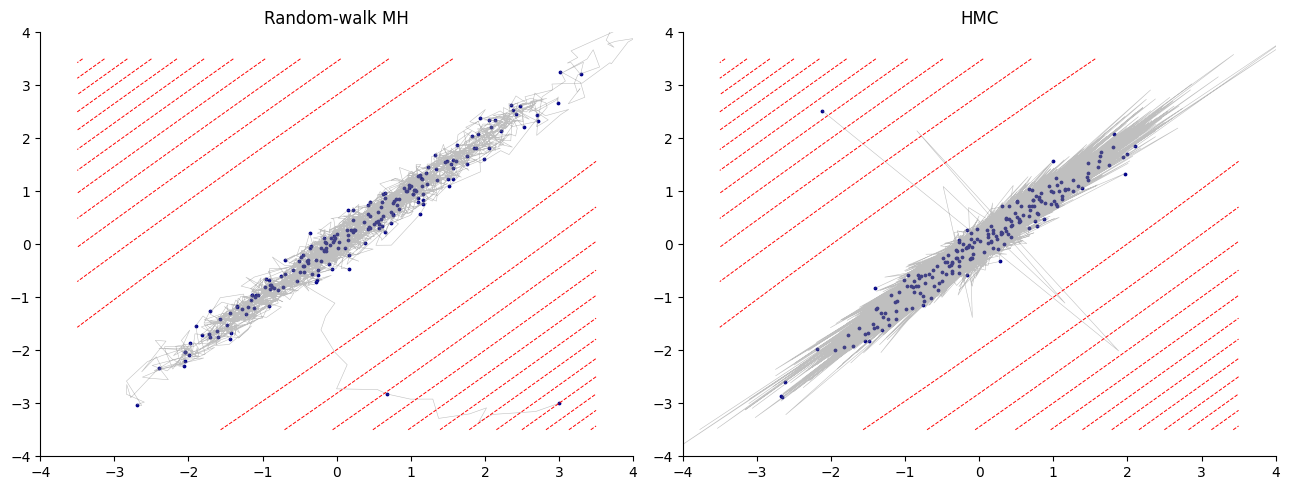

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, chain, title in zip(axes, [chain_mh, chain_hmc], ["Random-walk MH", "HMC"]):
    ax.plot(chain[:, 0], chain[:, 1], lw=0.4, alpha=0.5, color="grey")
    ax.scatter(chain[::20, 0], chain[::20, 1], s=3, color="darkblue")
    # Contour of true density
    grid = np.linspace(-3.5, 3.5, 100)
    xx, yy = np.meshgrid(grid, grid)
    pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
    log_pp = np.array([log_p(p) for p in pts]).reshape(xx.shape)
    ax.contour(xx, yy, log_pp, levels=12, colors="red", linewidths=0.7)
    ax.set_title(title)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.tight_layout(); plt.show()


In [5]:
# ESS comparison
def autocorr_time(x, max_lag=500):
    x = x - np.mean(x)
    var = np.var(x)
    n = len(x)
    rho = np.array([np.mean(x[:n-k] * x[k:]) / var for k in range(max_lag)])
    return 1 + 2 * np.sum(rho[1:][rho[1:] > 0])

burn = 500
for j in range(2):
    tau_mh = autocorr_time(chain_mh[burn:, j])
    tau_hmc = autocorr_time(chain_hmc[burn:, j])
    n_mh = len(chain_mh) - burn
    print(f"dim {j}:  MH ESS = {n_mh/tau_mh:7.1f}    HMC ESS = {n_mh/tau_hmc:7.1f}    "
          f"speedup = {(n_mh/tau_hmc)/(n_mh/tau_mh):.1f}x")


dim 0:  MH ESS =     8.9    HMC ESS =   293.3    speedup = 32.8x
dim 1:  MH ESS =     9.0    HMC ESS =   288.8    speedup = 32.1x


HMC explores the ridge an order of magnitude faster per sample. The improvement grows with dimension: in $D \gtrsim 50$ HMC routinely beats MH by **100× or more** in ESS-per-second.

## 4. Tuning HMC

HMC has two hyperparameters:
- **Step size** $\epsilon$: too small wastes computation; too large causes catastrophic energy errors and near-zero acceptance.
- **Number of leapfrog steps** $L$: too small means short trajectories that resemble random walk; too large wastes time on U-turns (the trajectory comes back near its starting point).

In practice, modern implementations use **NUTS** (No-U-Turn Sampler, Hoffman & Gelman 2014), which automatically chooses $L$ by detecting when the trajectory begins to "U-turn", and tunes $\epsilon$ via dual averaging during warmup. NUTS is the default sampler in `PyMC`, `NumPyro`, and `Stan`. Building it from scratch is a substantial exercise, but the leapfrog integrator and acceptance step above are its core.

## 5. Take-aways

- HMC trades evaluating $\nabla \log p$ for vastly better mixing — almost always worth it when gradients are available.
- The leapfrog integrator is symplectic; that is *the* reason HMC has bounded energy error and works at all.
- NUTS is what you use in practice; understanding HMC tells you how to debug a failing NUTS chain (divergences = bad geometry that needs reparametrisation).

## 6. Exercises

**Exercise 3.9.** Derive Hamilton's equations from $H(\theta, r) = -\log p(\theta) + \tfrac{1}{2} r^\top M^{-1} r$.

**Exercise 3.10 (Symplecticity).** Show that the leapfrog map has Jacobian determinant 1.

**Exercise 3.11 (Step-size tuning).** For the correlated Gaussian, scan $\epsilon \in [0.01, 0.5]$ at fixed $L=20$ and plot acceptance and ESS. Where is the sweet spot?

**Exercise 3.12 (HMC on Bayesian logistic regression).** Re-implement the logistic regression sampler from Lecture 1 using HMC and compare ESS-per-second.
